## Part 1: BeautifulSoup (CoinGecko)
Using what you learned from scraping CoinGecko:
1. Scrape the top 50 coins from CoinGecko and save the raw data to a CSV
2. Clean the numeric columns (price, market cap, volume, % changes)
3. Answer these questions using pandas:
    
    Which coin had the biggest 24h gain?
    
    Which coin had the biggest 24h loss?
    
    What is the total market cap of the top 50 coins combined?
    
    How many coins are down over 7 days?
4. Create two matplotlib charts of your choice that tell a story about the data. Each chart must have a title, labelled axes.


In [16]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

URL = "https://www.coingecko.com/"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0.0.0 Safari/537.36"
    )
}

response = requests.get(URL, headers=headers, timeout=20)
print(f"Status Code: {response.status_code}")
print(f"Page Size: {len(response.text):,} characters")


Status Code: 200
Page Size: 1,728,316 characters


In [17]:
soup = BeautifulSoup(response.text, "lxml")

print("Page Title:", soup.title.text.strip())

table = soup.find("table")

if table:
    print("Table found!")
    rows = table.find_all("tr")
    print(f"Rows found: {len(rows)}")
else:
    print("No table found.")

Page Title: Cryptocurrency Prices, Charts, and Crypto Market Cap | CoinGecko
Table found!
Rows found: 101


In [29]:
coin_data = []

tbody = table.find("tbody") if table else None

if tbody:
    for row in tbody.find_all("tr"):
        cells = row.find_all("td")
        if len(cells) < 8:
            continue

        rank        = cells[1].get_text(strip=True)
        name_cell   = cells[2].get_text(separator="|", strip=True).split("|")
        name        = name_cell[0] if name_cell else ""
        ticker      = name_cell[1] if len(name_cell) > 1 else ""

        price       = cells[4].get_text(strip=True)
        change_1h   = cells[5].get_text(strip=True)
        change_24h  = cells[6].get_text(strip=True)
        change_7d   = cells[7].get_text(strip=True)
        volume_24h  = cells[8].get_text(strip=True)
        market_cap  = cells[9].get_text(strip=True) if len(cells) > 8 else ""

        coin_data.append({
            "Rank":       rank,
            "Name":       name,
            "Ticker":     ticker,
            "Price":      price,
            "1h %":       change_1h,
            "24h %":      change_24h,
            "7d %":       change_7d,
            "Volume 24h": volume_24h,
            "Market Cap": market_cap
        })

df = pd.DataFrame(coin_data)
print(f"Scraped {len(df)} coins")
df.head(2)





Scraped 100 coins


,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
0,1,Bitcoin,BTC,"$77,522.26",0.0%,0.1%,2.4%,13.0%,"$18,559,593,819"
1,2,Ethereum,ETH,"$2,315.87",0.1%,0.1%,1.4%,13.1%,"$6,234,282,791"


In [27]:
df.to_csv("Coingecko_assignment_data.csv", index=False)
print("Saved!")


Saved!


In [ ]:
print(df.info())

In [42]:
#df['Price']         = df['Price'].str.replace('$', '').str.replace(',', '').astype(float)
# df['1h %']          = df['1h %'].str.replace('%', '').str.replace('-', '0').astype(float)
# df['24h %']         = df['24h %'].str.replace('%', '').str.replace('-', '0').astype(float)
# df['7d %']          = df['7d %'].str.replace('%', '').str.replace('-', '0').astype(float)
# df['Volume 24h']    = df['Volume 24h'].str.replace('%', '').str.replace('-', '0').astype(float)
#df['Market Cap']    = df['Market Cap'].str.replace('$', '').str.replace(',', '').str.replace('-', '0').astype('int64')
df['Market Cap']    = df['Market Cap'].astype('int64')

df.head(10)

,Rank,Name,Ticker,Price,1h %,24h %,7d %,Volume 24h,Market Cap
0,1,Bitcoin,BTC,77522.26000,0.0,0.1,2.4,13.0,18559593819
1,2,Ethereum,ETH,2315.87000,0.1,0.1,1.4,13.1,6234282791
2,3,Tether,USDT,1.00000,0.0,0.0,0.0,0.1,31458055834
3,4,XRP,XRP,1.42000,0.1,1.1,0.3,5.5,1054965244
4,5,BNB,BNB,629.55000,0.0,1.3,0.2,0.6,652319000
5,6,USDC,USDC,0.99990,0.0,0.0,0.0,0.0,5321863824
6,7,Solana,SOL,85.91000,0.1,0.7,0.3,0.3,1671494190
7,8,TRON,TRX,0.32400,0.0,0.1,1.7,4.8,394509673
8,9,Figure Heloc,FIGR_HELOC,1.02000,0.0,2.0,1.4,0.4,28914
9,10,Dogecoin,DOGE,0.09801,0.2,0.7,3.1,7.5,901234875


In [ ]:
df_top50 = df.head(50).copy()
df_top50

In [52]:
df_24h_max = df_top50['24h %'].max()

max_idx = df_top50['24h %'].idxmax()

coin_name = df_top50.loc[max_idx, 'Name']

coin_ticker = df_top50.loc[max_idx, 'Ticker']

print(f"The coin with the highest 24 hour gain is: {coin_name}({coin_ticker}), it did {df_24h_max}")

The coin with the highest 24 hour gain is: Rain(RAIN), it did 6.7


In [54]:
df_24h_min = df_top50['24h %'].min()

min_idx = df_top50['24h %'].idxmin()

coin_name = df_top50.loc[min_idx, 'Name']

coin_ticker = df_top50.loc[min_idx, 'Ticker']

print(f"The coin with the lowest 24 hour gain is: {coin_name}({coin_ticker}), it did {df_24h_min}")

The coin with the lowest 24 hour gain is: Tether(USDT), it did 0.0


In [57]:
sum_mkt_cap = sum(df_top50['Market Cap'])
sum_mkt_cap

print(f"Total Market Cap (Top 50): ${sum_mkt_cap:,} ")

Total Market Cap (Top 50): $69,862,366,978 


In [64]:
coins_down_7d = df_top50['7d %'] < 0

losers = df_top50[coins_down_7d]

print(f"Number of coins down over 7 days: {len(losers)}")

Number of coins down over 7 days: 0


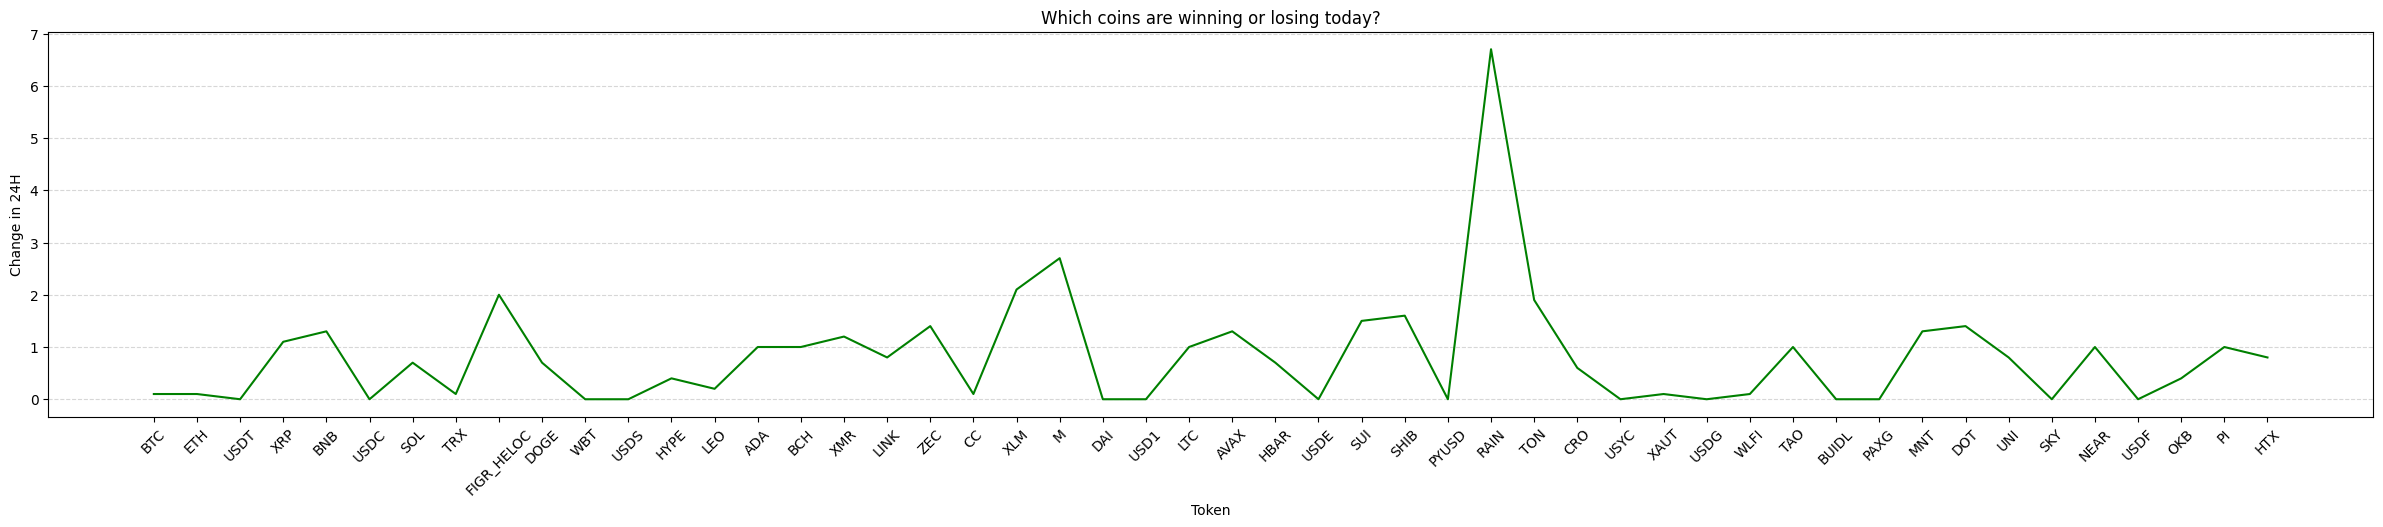

In [93]:
import matplotlib.pyplot as plt

plt.figure (figsize = (30, 5))

plt.plot(df_top50['Ticker'], df_top50['24h %'], color = 'green')

plt.title('Which coins are winning or losing today?')
plt.xlabel('Token')
plt.ylabel('Change in 24H')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
plt.show()

Create two matplotlib charts of your choice that tell a story about the data. Each chart must have a title, labelled axes.

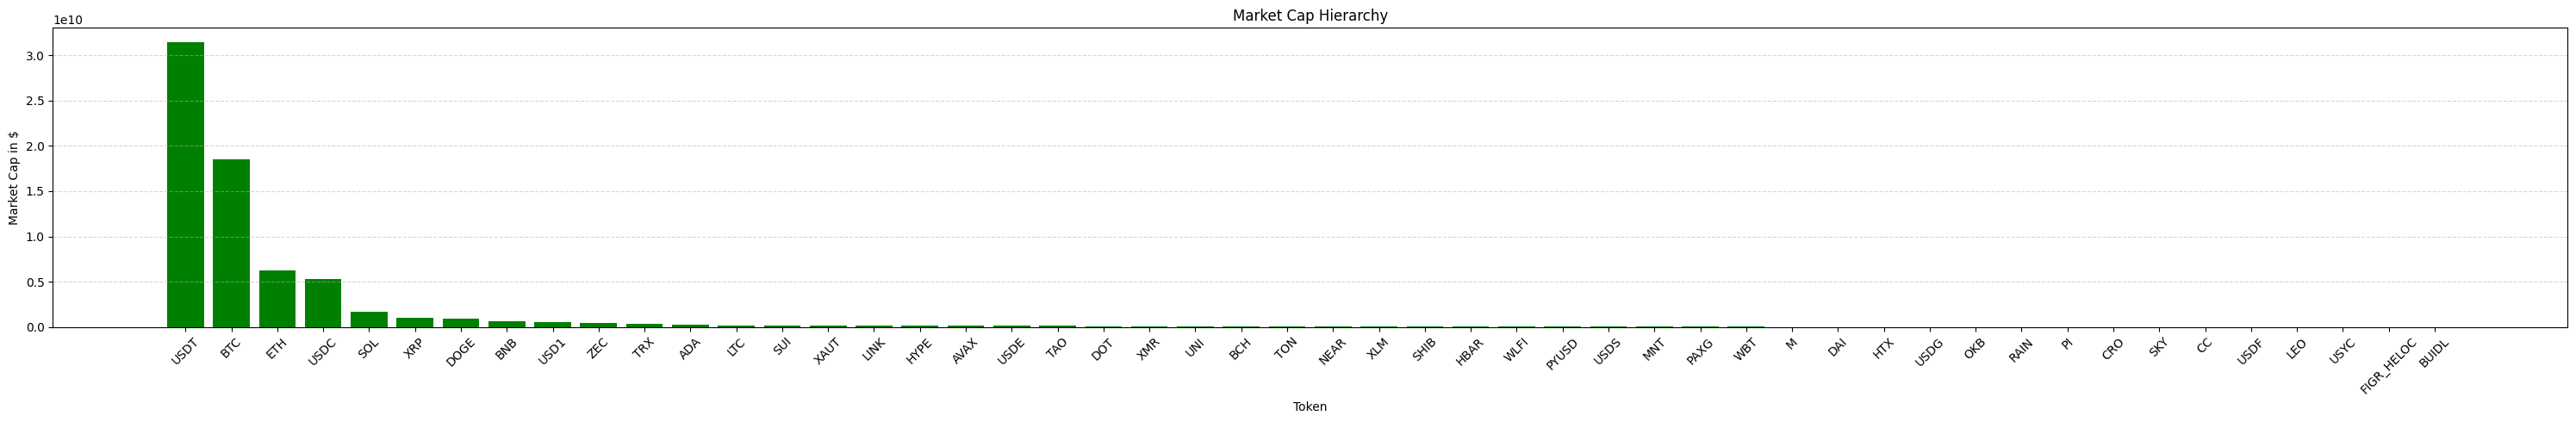

In [101]:
df_sorted = df_top50.sort_values(by='Market Cap', ascending=False)

plt.figure (figsize = (30, 5))

plt.bar(df_sorted['Ticker'], df_sorted['Market Cap'], color = 'green')

plt.title('Market Cap Hierarchy')
plt.xlabel('Token')
plt.ylabel('Market Cap in $')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()